In [1]:
import pandas as pd

df = pd.read_parquet('../data/raw/yellow_tripdata_2025-03.parquet')

In [2]:
# Данных значительно больше, раньше их было около 3.5 миллионов
df.shape

(4145257, 20)

In [3]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2618534,2,2025-03-26 10:09:12,2025-03-26 10:14:37,1.0,0.61,1.0,N,211,231,1,6.5,0.0,0.5,2.25,0.0,1.0,13.50,2.5,0.0,0.75
2786066,2,2025-03-27 19:35:43,2025-03-27 19:57:14,1.0,2.51,1.0,N,229,186,1,19.8,2.5,0.5,5.41,0.0,1.0,32.46,2.5,0.0,0.75
1059646,2,2025-03-11 13:03:48,2025-03-11 13:04:09,1.0,0.00,1.0,N,236,236,4,-3.0,0.0,-0.5,0.00,0.0,-1.0,-7.00,-2.5,0.0,0.00


In [4]:
df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          916663
trip_distance                 0
RatecodeID               916663
store_and_fwd_flag       916663
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     916663
Airport_fee              916663
cbd_congestion_fee            0
dtype: int64

In [5]:
# ЧАСТЬ 1: ПРОПУСКИ И ДУБЛИКАТЫ
# строки с хотя бы одним NaN — это ровно те же строки, где payment_type == 0

df.index[df.isna().any(axis=1)].equals(df.index[df["payment_type"] == 0])

True

In [6]:
df[df.duplicated()].shape

(0, 20)

In [7]:
# ЧАСТЬ 2: МИНИМАЛЬНАЯ ОЧИСТКА ДАННЫХ
mask_1 = df["tpep_pickup_datetime"] > df["tpep_dropoff_datetime"]
mask_2 = (df["tpep_pickup_datetime"] == df["tpep_dropoff_datetime"]) & (df['trip_distance'] != 0)
mask_3 = (df["tpep_pickup_datetime"] < '2025-03-01') | (df["tpep_pickup_datetime"] >= '2025-04-01')
df[mask_1 | mask_2 | mask_3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
8,2,2025-02-28 23:50:41,2025-03-01 00:03:51,1.0,2.09,1.0,N,79,186,1,13.50,1.0,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
84,2,2025-02-28 23:58:42,2025-03-01 00:02:23,3.0,0.83,1.0,N,170,107,1,5.80,1.0,0.5,1.00,0.0,1.0,12.55,2.5,0.0,0.75
168,7,2025-03-01 00:30:08,2025-03-01 00:30:08,1.0,1.33,1.0,N,234,161,1,7.90,0.0,0.5,2.73,0.0,1.0,16.38,2.5,0.0,0.75
208,2,2025-02-28 23:54:26,2025-03-01 00:07:45,1.0,1.55,1.0,N,114,158,1,12.80,1.0,0.5,1.00,0.0,1.0,19.55,2.5,0.0,0.75
361,2,2025-02-28 23:59:24,2025-03-01 00:05:32,1.0,1.47,1.0,N,79,186,1,8.60,1.0,0.5,2.87,0.0,1.0,17.22,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4009093,6,2025-03-28 12:03:40,2025-03-28 12:03:18,NaN,8.69,NaN,None,83,10,0,2.90,0.0,0.5,0.00,0.0,0.3,27.96,NaN,NaN,0.00
4034335,2,2025-03-29 02:58:00,2025-03-29 02:58:00,NaN,0.15,NaN,None,4,79,0,9.53,0.0,0.5,0.00,0.0,1.0,14.28,NaN,NaN,0.75
4099645,6,2025-03-30 13:03:31,2025-03-30 13:03:01,NaN,4.90,NaN,None,160,197,0,2.90,0.0,0.5,0.00,0.0,0.3,22.02,NaN,NaN,0.00
4101116,2,2025-03-30 14:00:00,2025-03-30 14:00:00,NaN,0.02,NaN,None,166,166,0,12.38,0.0,0.5,1.39,0.0,1.0,15.27,NaN,NaN,0.00


In [8]:
# Найдено 21551 проблемных строк — около 0.5% исходной выборки.
# Удалим эти записи.
df = df[~(mask_1 | mask_2 | mask_3)]

In [10]:
# проверяю PULocationID, DOLocationID
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")
valid_ids = set(zones["LocationID"])
print('записей с несуществующими зонами посадки:', df[~(df["PULocationID"].isin(valid_ids))].shape[0])
print('записей с несуществующими зонами высадки:', df[~(df["DOLocationID"].isin(valid_ids))].shape[0])

записей с несуществующими зонами посадки: 0
записей с несуществующими зонами высадки: 0


In [11]:
df[df["PULocationID"] == 264]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
451,1,2025-03-01 00:04:33,2025-03-01 00:22:40,5.0,3.30,1.0,N,264,264,2,17.7,1.00,0.5,0.00,0.00,1.0,20.20,0.0,0.0,0.00
452,1,2025-03-01 00:28:27,2025-03-01 00:53:10,5.0,5.20,1.0,N,264,264,1,24.7,1.00,0.5,5.00,3.25,1.0,35.45,0.0,0.0,0.00
2617,1,2025-03-01 00:20:51,2025-03-01 00:29:33,2.0,1.20,1.0,N,264,264,1,10.0,4.25,0.5,3.15,0.00,1.0,18.90,2.5,0.0,0.75
2619,1,2025-03-01 00:51:21,2025-03-01 01:11:30,1.0,6.20,1.0,N,264,264,1,29.6,4.25,0.5,7.05,0.00,1.0,42.40,2.5,0.0,0.75
3811,2,2025-03-01 00:20:15,2025-03-01 00:32:02,1.0,2.14,1.0,N,264,264,1,13.5,1.00,0.5,2.88,0.00,1.0,22.13,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4125902,1,2025-03-31 07:53:55,2025-03-31 08:26:16,NaN,12.30,NaN,None,264,230,0,49.2,0.00,0.5,6.58,11.94,1.0,72.47,NaN,NaN,0.75
4128341,1,2025-03-31 10:52:52,2025-03-31 11:03:16,NaN,1.60,NaN,None,264,264,0,11.4,0.00,0.5,2.42,0.00,1.0,18.57,NaN,NaN,0.75
4129754,1,2025-03-31 12:15:52,2025-03-31 12:22:39,NaN,1.30,NaN,None,264,264,0,8.6,0.00,0.5,1.26,0.00,1.0,13.86,NaN,NaN,0.00
4132381,1,2025-03-31 16:55:50,2025-03-31 17:09:33,NaN,1.90,NaN,None,264,239,0,14.9,2.50,0.5,3.21,0.00,1.0,24.61,NaN,NaN,0.00


In [12]:
# записей с зоной 264 всего 7638
# Для анализа локального спроса нужна известная зона посадки,
# поэтому удаляю 7638 записей с PULocationID = 264.
df = df[df["PULocationID"] != 264]

In [13]:
# ЧАСТЬ 3: EDA
print('удалено записей из таблицы:', 4145257-df.shape[0])
print('осталось записей о поездке:', df.shape[0])
print('максимальная и минимальная даты в таблице:', df['tpep_pickup_datetime'].max(), df['tpep_pickup_datetime'].min())

удалено записей из таблицы: 29189
осталось записей о поездке: 4116068
максимальная и минимальная даты в таблице: 2025-03-31 23:59:59 2025-03-01 00:00:00


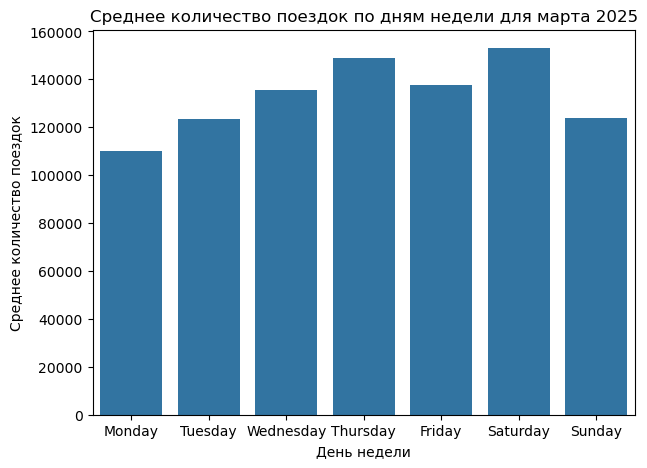

In [14]:
# рассмотрим распределение записей по дням недели (считая для начала поездки) и визуализируем
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))
first_group = df.groupby(df['tpep_pickup_datetime'].dt.date).size()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
second_group = first_group.groupby(pd.to_datetime(first_group.index).day_name()).mean()
second_group = second_group.reindex(weekday_order)
sns.barplot(data=second_group).set(title='Среднее количество поездок по дням недели для марта 2025',
                                   xlabel='День недели',
                                   ylabel='Среднее количество поездок');

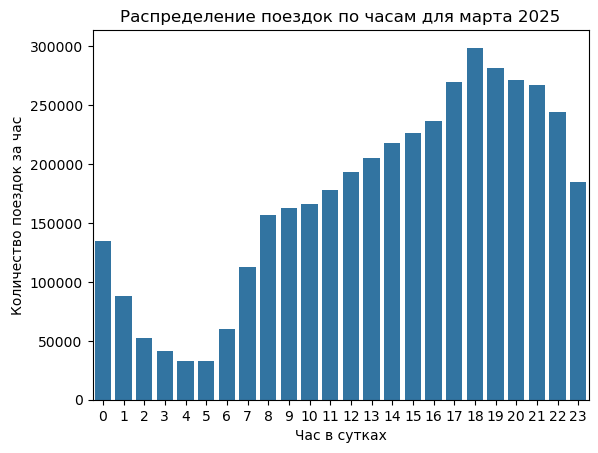

In [15]:
# рассмотрим распределение записей по часам и визуализируем
gr = df.groupby(df['tpep_pickup_datetime'].dt.hour).size()
sns.barplot(data=gr).set(
    title='Распределение поездок по часам для марта 2025', 
    xlabel='Час в сутках', 
    ylabel='Количество поездок за час');

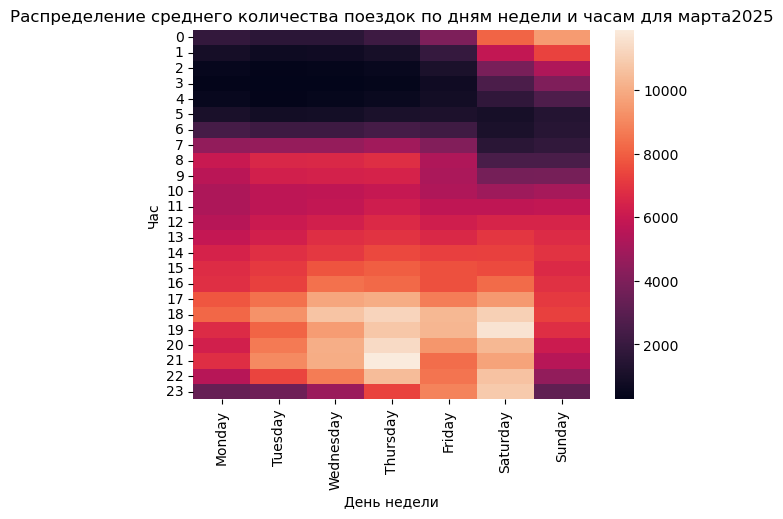

In [16]:
# Посмотрим среднее количество поездок по дню недели и часу
day_hour = df.groupby([
    df["tpep_pickup_datetime"].dt.date.rename("date"), 
    df["tpep_pickup_datetime"].dt.day_name().rename("day_of_week"), 
    df["tpep_pickup_datetime"].dt.hour.rename("hour")]).size().rename("trips")
day_hour = day_hour.reset_index()

day_hour = day_hour.groupby([
    day_hour["day_of_week"],
    day_hour["hour"]])["trips"].mean()
day_hour = day_hour.reset_index()


day_hour = day_hour.pivot(columns="day_of_week", index="hour", values="trips")
day_hour = day_hour[weekday_order]

sns.heatmap(day_hour).set(title="Распределение среднего количества поездок по дням недели и часам для марта 2025", 
                          xlabel="День недели", 
                          ylabel="Час");

In [17]:
# На графике распределения среднего количества поездок по дням недели заметно 
# понижение уровня в пятницу по сравнению с февральским графиком.
# Хитмап для распределения 'день недели x час' тоже в целом похож, но имеет малые отклонения:
# заметно увеличение количества поездок в субботу и четверг вечером, теперь пик активности приходится на четверг в 21 и субботу в 19

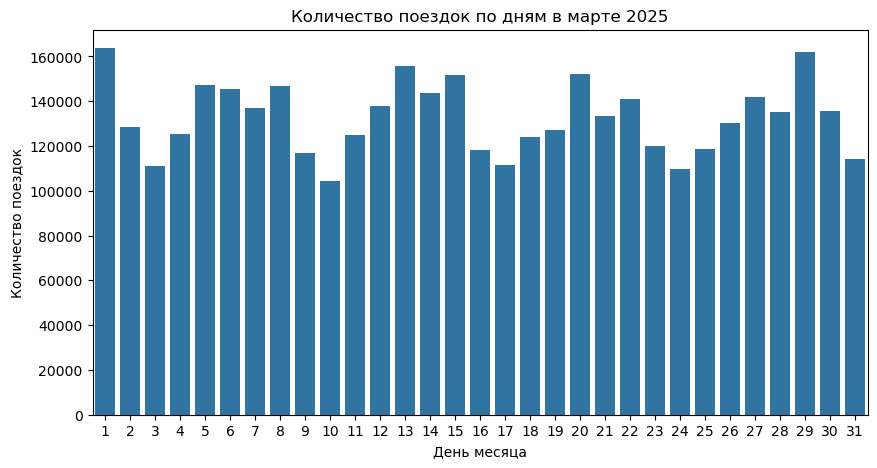

In [19]:
# Рассмотрим спрос на такси в конкретные даты

from datetime import date


gr_date = df.groupby(df["tpep_pickup_datetime"].dt.date.rename("date")).size().rename("trips")
gr_date = gr_date.to_frame()

gr_date = gr_date.reset_index()
gr_date["date"] = pd.to_datetime(gr_date["date"])
gr_date["date"] = gr_date["date"].dt.day

plt.figure(figsize=(10, 5))
sns.barplot(data=gr_date, x="date", y="trips").set(
    title="Количество поездок по дням в марте 2025", 
    xlabel="День месяца", 
    ylabel="Количество поездок");

# Сохраняется недельная цикличность.
# Особенно низкие значения наблюдаются по понедельникам: 3, 10, 17, 24, 31 числа.

In [20]:
# Зона посадки PULocationID

start_zone_borough = df.groupby(df["PULocationID"]).size().rename("trips")
start_zone_borough = start_zone_borough.to_frame()
start_zone_borough = start_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
start_zone_borough = start_zone_borough.set_index("LocationID")
start_borough = start_zone_borough.groupby(start_zone_borough["Borough"])["trips"].sum().sort_values()
start_borough = start_borough.to_frame()
start_borough
# ожидаемо, поездки на жёлтых такси всё так же преобладают на Манхэттене

,trips
Borough,
EWR,365
Staten Island,429
Bronx,34192
Brooklyn,143060
Queens,377668
Manhattan,3558806


In [21]:
# ЧАСТЬ 4: ИСКОМЫЕ ДАННЫЕ
venue_zone_ids = [79, 161, 163, 186, 239]

df_selected = df[
    df["PULocationID"].isin(venue_zone_ids)
]

data_pickup = (
    df_selected
    .groupby([
        df_selected["tpep_pickup_datetime"].dt.floor("D").rename("date"),
        df_selected["tpep_pickup_datetime"].dt.hour.rename("hour"),
        df_selected["PULocationID"].rename("LocationID")
    ])
    .size()
    .rename("pickups")
    .reset_index()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-03-01,0,79,788
1,2025-03-01,0,161,163
2,2025-03-01,0,163,127
3,2025-03-01,0,186,167
4,2025-03-01,0,239,105
...,...,...,...,...
3705,2025-03-31,23,79,109
3706,2025-03-31,23,161,172
3707,2025-03-31,23,163,84
3708,2025-03-31,23,186,127


In [22]:
# В таблице должно быть 31 день x 24 часа x 5 зон = 3720 записей,
# сейчас в таблице 3710 записей, пропуск строки значит, что в этот день, в этот час, в этом районе
# не было ни одной поездки на такси. Найдём такие записи и запишем для них 0 в pickups

full_index = pd.MultiIndex.from_product(
    [
        pd.date_range("2025-03-01", "2025-03-31", freq="D"),
        range(24),
        venue_zone_ids
    ],
    names=["date", "hour", "LocationID"]
)

data_pickup = (
    data_pickup
    .set_index(["date", "hour", "LocationID"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

assert (
    data_pickup["pickups"].sum()
    ==
    df["PULocationID"].isin(venue_zone_ids).sum()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-03-01,0,79,788
1,2025-03-01,0,161,163
2,2025-03-01,0,163,127
3,2025-03-01,0,186,167
4,2025-03-01,0,239,105
...,...,...,...,...
3715,2025-03-31,23,79,109
3716,2025-03-31,23,161,172
3717,2025-03-31,23,163,84
3718,2025-03-31,23,186,127


In [24]:
# ЧАСТЬ 5: СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

from pathlib import Path

processed_taxi_dir = Path("../data/processed/taxi")
processed_taxi_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    processed_taxi_dir
    / "yellow_taxi_pickups_2025_03.parquet"
)

data_pickup.to_parquet(
    output_path,
    index=False
)

In [25]:
data_pickup_check = pd.read_parquet(output_path)

print("Размер:", data_pickup_check.shape)
print(
    "Дубликаты:",
    data_pickup_check.duplicated(
        subset=["date", "hour", "LocationID"]
    ).sum()
)
print("Пропуски:", data_pickup_check.isna().sum().sum())
print("Количество зон:", data_pickup_check["LocationID"].nunique())

assert data_pickup_check.equals(data_pickup)

Размер: (3720, 4)
Дубликаты: 0
Пропуски: 0
Количество зон: 5
